In [1]:
from tqdm import tqdm
import matplotlib.pyplot as plt
from utils import *

In [2]:
def ghz_001_mixture(p):
    ghz =numqi.state.GHZ(3)
    # 001 state
    psi_001 = np.array([0, 1, 0, 0, 0, 0, 0, 0])
    rho_001 = psi_001[:, np.newaxis] @ psi_001[np.newaxis, :]
    rho_ghz = ghz[:, np.newaxis] * ghz[np.newaxis, :]
    return (1-p)*rho_ghz + p*rho_001

In [5]:
distance_list = []
p_list = np.linspace(0, 1, 50)
model = GenuineHilbertSchmidtMeasure(dim_list=[2,2,2], num_ensemble=2*16, distance='fidelity', dtype=torch.complex128)
for p in tqdm(p_list):
    rho = ghz_001_mixture(p)
    model.set_target_rho(rho)
    theta_optim = numqi.optimize.minimize(model, num_repeat=3, tol=1e-10, print_every_round=0)
    info = model(return_info=True)[1]
    distance_list.append(info['distance'])

100%|██████████| 50/50 [00:10<00:00,  4.84it/s]


Text(0.5, 1.0, 'GHZ-001 mixture')

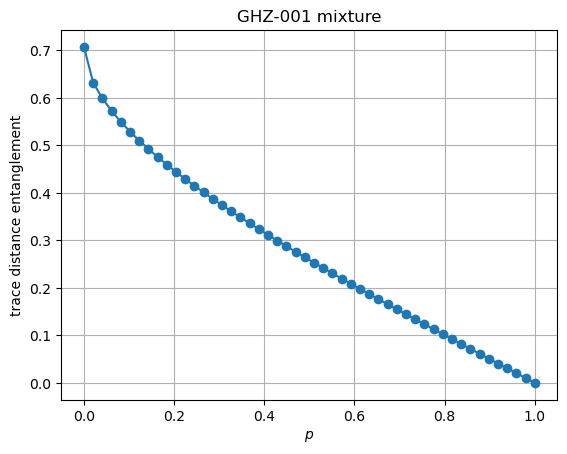

In [7]:
fig, ax = plt.subplots()
ax.plot(p_list, distance_list, marker='o')
ax.set_xlabel(r'$p$')
ax.grid()
ax.set_ylabel(r'trace distance entanglement')
ax.set_title('GHZ-001 mixture')